<a href="https://colab.research.google.com/github/MohamedKhattab-pharma/Drug-Discovery-AI-in-CADD/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bioactivity_preprocessed_data.csv to bioactivity_preprocessed_data (1).csv


In [ ]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL2105759,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,81.9,active
1,CHEMBL2105759,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,149.0,active
2,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,229.0,active
3,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,409.0,active
4,CHEMBL1789941,N#CC[C@H](C1CCCC1)n1cc(-c2ncnc3[nH]ccc23)cn1,818.0,active
5,CHEMBL1789941,N#CC[C@H](C1CCCC1)n1cc(-c2ncnc3[nH]ccc23)cn1,1090.0,intermediate
6,CHEMBL3301607,O=C(Nc1nc2cccc(-c3ccc(CN4CCS(=O)(=O)CC4)cc3)n2...,10123.0,inactive
7,CHEMBL3039513,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,11200.0,inactive
8,CHEMBL3301607,O=C(Nc1nc2cccc(-c3ccc(CN4CCS(=O)(=O)CC4)cc3)n2...,13362.0,inactive
9,CHEMBL3039513,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,16400.0,inactive


In [ ]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)


Original shape: (68, 4)
After cleaning: (58, 4)


In [ ]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()

Before aggregation: 58
After aggregation: 45


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,CHEMBL3765822,230.0,active
1,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,CHEMBL3655081,15062.5,inactive
2,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,CHEMBL2105759,149.0,active
3,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,CHEMBL3039513,13800.0,inactive
4,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,CHEMBL4516272,11000.0,inactive


In [ ]:
df_clean.standard_value.describe()

,standard_value
count,45.000000
mean,1643.342511
std,4033.337671
min,0.053000
25%,63.000000
50%,249.000000
75%,500.000000
max,15062.500000


In [ ]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()

,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,CHEMBL3765822,230.0,active,6.638272
1,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,CHEMBL3655081,15062.5,inactive,4.822103
2,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,CHEMBL2105759,149.0,active,6.826814
3,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,CHEMBL3039513,13800.0,inactive,4.860121
4,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,CHEMBL4516272,11000.0,inactive,4.958607


In [ ]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()

,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,CHEMBL3765822,230.0,active,6.638272
1,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,CHEMBL3655081,15062.5,inactive,4.822103
2,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,CHEMBL2105759,149.0,active,6.826814
3,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,CHEMBL3039513,13800.0,inactive,4.860121
4,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,CHEMBL4516272,11000.0,inactive,4.958607


In [ ]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())


Duplicate SMILES remaining: 0


In [ ]:
df_clean.standard_value.describe()

,standard_value
count,45.000000
mean,1643.342511
std,4033.337671
min,0.053000
25%,63.000000
50%,249.000000
75%,500.000000
max,15062.500000


In [ ]:
df_clean.pIC50.describe()

,pIC50
count,45.000000
mean,6.960005
std,1.324324
min,4.822103
25%,6.301030
50%,6.603801
75%,7.200659
max,10.275724


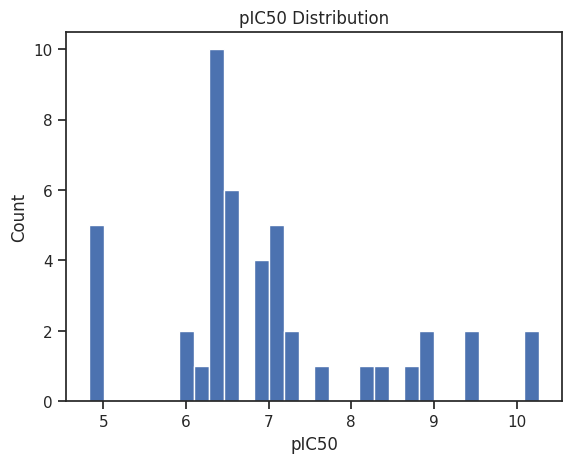

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.hist(df_clean["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

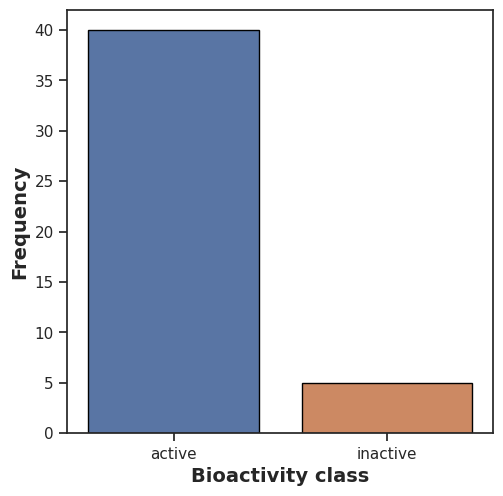

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.savefig('Barplot_Bioactivity_values.pdf')

In [ ]:
!pip install rdkit

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [ ]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL3765822,230.000,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...
1,CHEMBL3655081,15062.500,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...
2,CHEMBL2105759,149.000,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...
3,CHEMBL3039513,13800.000,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...
4,CHEMBL4516272,11000.000,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O
5,CHEMBL4438202,430.000,active,6.366532,CNC(=O)c1cnc(NC(=O)C2CC2)cc1Nc1ccccc1S(C)(=O)=O
6,CHEMBL4548200,27.000,active,7.568636,CNC(=O)c1cnc(Nc2cc(C)ccn2)cc1Nc1ccccc1S(C)(=O)=O
7,CHEMBL4453545,490.000,active,6.309804,CNC(=O)c1cnc(Nc2ccc(C)nn2)cc1Nc1ccccc1S(C)(=O)=O
8,CHEMBL4476830,380.000,active,6.420216,CNC(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccc(F)c(F)c1OC
9,CHEMBL4537678,660.000,active,6.180456,CNC(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O


In [ ]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,358.446,2.15170,3.0,5.0
1,323.422,1.25450,2.0,5.0
2,371.426,1.09568,1.0,6.0
3,392.385,3.27900,3.0,5.0
4,394.410,2.90360,3.0,6.0


In [ ]:
df_lipinski.shape

(45, 4)

In [ ]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL3765822,230.0,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...
1,CHEMBL3655081,15062.5,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...
2,CHEMBL2105759,149.0,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...
3,CHEMBL3039513,13800.0,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...
4,CHEMBL4516272,11000.0,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O


In [ ]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,358.446,2.15170,3.0,5.0
1,323.422,1.25450,2.0,5.0
2,371.426,1.09568,1.0,6.0
3,392.385,3.27900,3.0,5.0
4,394.410,2.90360,3.0,6.0


In [ ]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3765822,230.0,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,358.446,2.15170,3.0,5.0
1,CHEMBL3655081,15062.5,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,323.422,1.25450,2.0,5.0
2,CHEMBL2105759,149.0,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,371.426,1.09568,1.0,6.0
3,CHEMBL3039513,13800.0,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,392.385,3.27900,3.0,5.0
4,CHEMBL4516272,11000.0,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,394.410,2.90360,3.0,6.0


In [ ]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3765822,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,358.446,2.15170,3.0,5.0
1,CHEMBL3655081,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,323.422,1.25450,2.0,5.0
2,CHEMBL2105759,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,371.426,1.09568,1.0,6.0
3,CHEMBL3039513,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,392.385,3.27900,3.0,5.0
4,CHEMBL4516272,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,394.410,2.90360,3.0,6.0


In [ ]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)

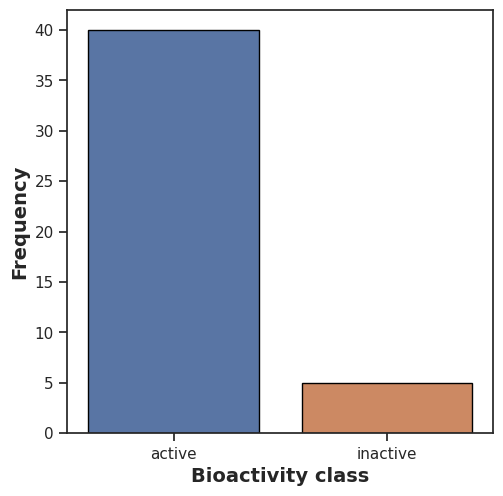

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_combined, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

Text(0, 0.5, 'pIC50 value')

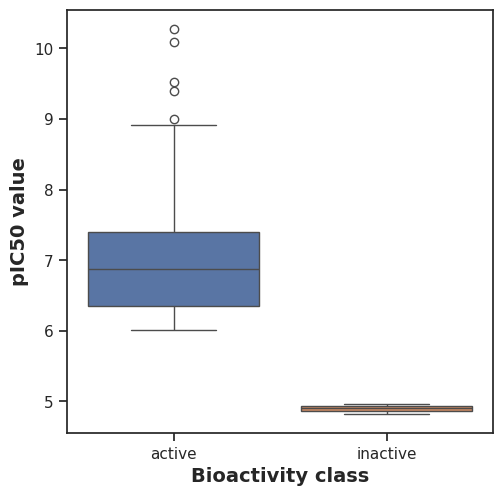

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "pIC50", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

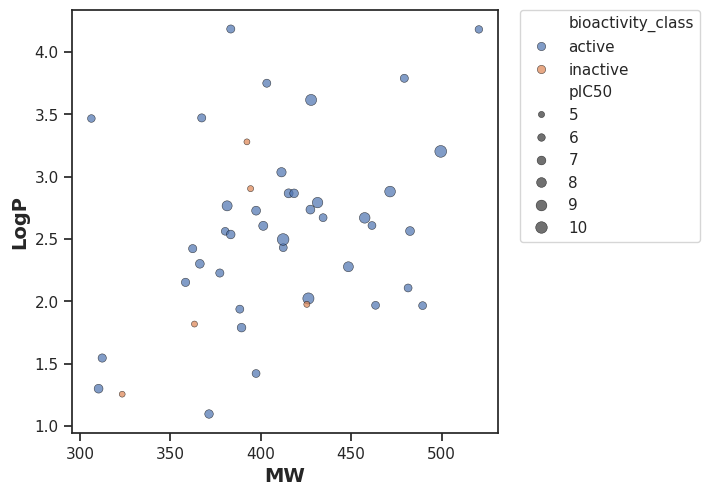

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

In [ ]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and inactive compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, bioactivity_class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns
    df = df_combined[[descriptor, 'bioactivity_class']]

    # separate active and inactive compounds
    active = df[df['bioactivity_class'] == 'active'][descriptor]
    inactive = df[df['bioactivity_class'] == 'inactive'][descriptor]

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results


In [ ]:
mannwhitney("pIC50", df_combined, verbose=True)

Descriptor: pIC50
Statistics=200.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,200.0,0.000321,0.05,Different distribution (reject H0)


In [ ]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=138.000, p=0.181


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,138.0,0.181386,0.05,Same distribution (fail to reject H0)


In [ ]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=122.000, p=0.437


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,122.0,0.437445,0.05,Same distribution (fail to reject H0)


In [ ]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=91.500, p=0.761


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,91.5,0.761499,0.05,Same distribution (fail to reject H0)


In [ ]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=149.500, p=0.069


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,149.5,0.068623,0.05,Same distribution (fail to reject H0)


In [ ]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


In [ ]:
mw_combined

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,138.0,0.181386,0.05,Same distribution (fail to reject H0)
1,NumHAcceptors,149.5,0.068623,0.05,Same distribution (fail to reject H0)
2,LogP,122.0,0.437445,0.05,Same distribution (fail to reject H0)
3,pIC50,200.0,0.000321,0.05,Different distribution (reject H0)
4,NumHDonors,91.5,0.761499,0.05,Same distribution (fail to reject H0)


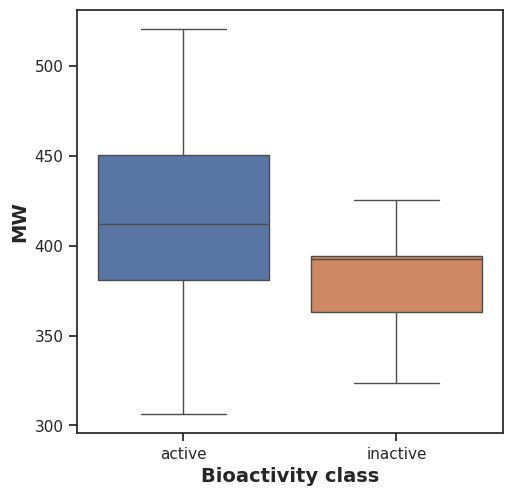

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')

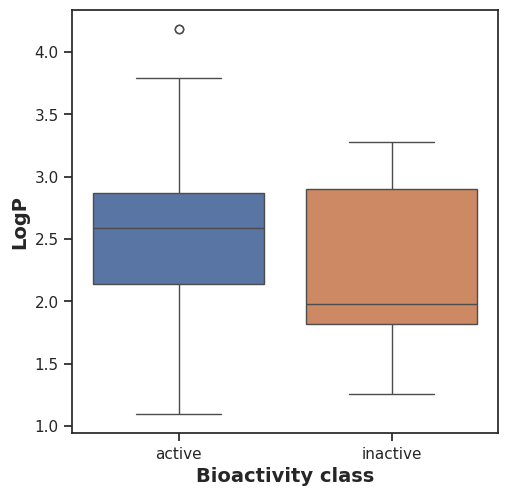

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = 'LogP', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

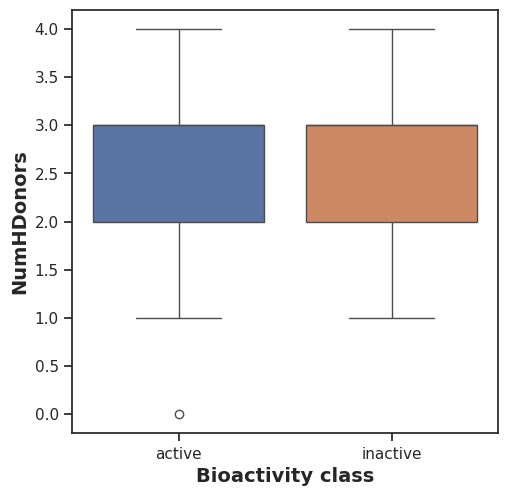

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHDonors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

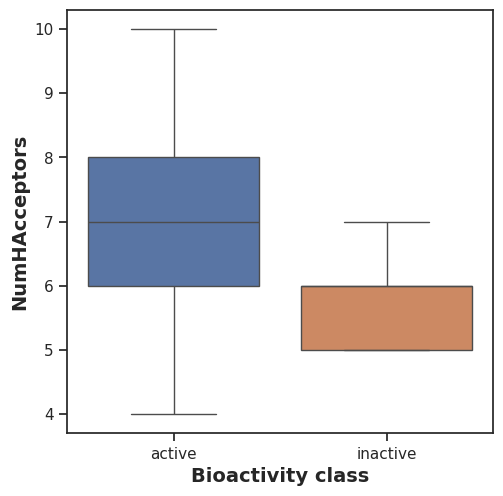

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHAcceptors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')

In [ ]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

  adding: boxplot_NumHAcceptors.pdf (deflated 37%)
  adding: mannwhitney_summary.csv (deflated 50%)
  adding: boxplot_MW.pdf (deflated 39%)
  adding: boxplot_NumHDonors.pdf (deflated 37%)
  adding: df_lipinski.csv (deflated 66%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 22%)
  adding: boxplot_LogP.pdf (deflated 38%)
  adding: Barplot_Bioactivity_values.pdf (deflated 38%)
  adding: histogram_pic50.pdf (deflated 49%)
  adding: barplot_bioactivity_class.pdf (deflated 38%)


Second part


In [ ]:
!pip install padelpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 22.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from padelpy import padeldescriptor

In [ ]:
df = pd.read_csv('df_lipinski.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3765822,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,358.446,2.15170,3.0,5.0
1,CHEMBL3655081,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,323.422,1.25450,2.0,5.0
2,CHEMBL2105759,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,371.426,1.09568,1.0,6.0
3,CHEMBL3039513,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,392.385,3.27900,3.0,5.0
4,CHEMBL4516272,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,394.410,2.90360,3.0,6.0


In [ ]:
data = df[['canonical_smiles', 'molecule_chembl_id']]
data.head()

,canonical_smiles,molecule_chembl_id
0,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,CHEMBL3765822
1,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,CHEMBL3655081
2,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,CHEMBL2105759
3,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,CHEMBL3039513
4,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,CHEMBL4516272


In [ ]:
df_smi = data['canonical_smiles'].to_csv('smiles_chembl.smi', index=None, header=None)

In [ ]:
! cat smiles_chembl.smi | head

CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH]nc(N)c2c1=O
CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc23)C1
CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)cn2)C1
CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)NCC(F)(F)F
CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O
CNC(=O)c1cnc(NC(=O)C2CC2)cc1Nc1ccccc1S(C)(=O)=O
CNC(=O)c1cnc(Nc2cc(C)ccn2)cc1Nc1ccccc1S(C)(=O)=O
CNC(=O)c1cnc(Nc2ccc(C)nn2)cc1Nc1ccccc1S(C)(=O)=O
CNC(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccc(F)c(F)c1OC
CNC(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O


In [ ]:
padeldescriptor(mol_dir= "smiles_chembl.smi",
                d_file='pubchem_fingerprints.csv',
                fingerprints = True,
                retainorder= True,
                retain3d= True,
                #removesalt = True, standardizetautomers = True, standardizenitro=True
                )

In [ ]:
!ls -lh pubchem_fingerprints.csv

-rw-r--r-- 1 root root 90K Feb 21 14:30 pubchem_fingerprints.csv


In [ ]:
df_fingerprint = pd.read_csv("pubchem_fingerprints.csv")
df_fingerprint.head()


,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_smiles_chembl_1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_smiles_chembl_2,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_smiles_chembl_3,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_smiles_chembl_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_smiles_chembl_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL3765822,active,6.638272,CC(C)[C@@H](C)n1cc(-c2cc(C(C)(C)O)n(C)n2)c2[nH...,358.446,2.15170,3.0,5.0
1,CHEMBL3655081,inactive,4.822103,CCCS(=O)(=O)N[C@H]1C[C@@H](N(C)c2ncnc3[nH]ccc2...,323.422,1.25450,2.0,5.0
2,CHEMBL2105759,active,6.826814,CCS(=O)(=O)N1CC(CC#N)(n2cc(-c3ncnc4[nH]ccc34)c...,371.426,1.09568,1.0,6.0
3,CHEMBL3039513,inactive,4.860121,CC[C@@](C)(Nc1ccnc(-c2c[nH]c3ncccc23)n1)C(=O)N...,392.385,3.27900,3.0,5.0
4,CHEMBL4516272,inactive,4.958607,CN(C)C(=O)c1cnc(Nc2ccc(F)cn2)cc1Nc1ccccc1C(N)=O,394.410,2.90360,3.0,6.0


In [ ]:
# Select only the columns we need for ML
meta_cols = df[['molecule_chembl_id', 'bioactivity_class', 'pIC50']]

# Reset index to ensure proper alignment
meta_cols = meta_cols.reset_index(drop=True)
df_fingerprint = df_fingerprint.reset_index(drop=True)

# Combine meta data with fingerprints
combined_df = pd.concat([meta_cols, df_fingerprint.drop(df_fingerprint.columns[0], axis=1)], axis=1)

# Inspect the first few rows
combined_df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL3765822,active,6.638272,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL3655081,inactive,4.822103,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL2105759,active,6.826814,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL3039513,inactive,4.860121,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL4516272,inactive,4.958607,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Save as CSV
combined_df.to_csv("QSAR_dataset.csv", index=False)
print("Combined dataset saved as QSAR_dataset.csv")

# Download file in Colab
files.download("QSAR_dataset.csv")

Combined dataset saved as QSAR_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculating fingerprints

In [ ]:
!wget https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip


--2026-02-21 14:31:55--  https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip [following]
--2026-02-21 14:31:55--  https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘padel_descriptors_xml.zip’

padel_descriptors_x 100%[=============

In [ ]:
!unzip padel_descriptors_xml.zip

Archive:  padel_descriptors_xml.zip
  inflating: AtomPairs2DFingerprintCount.xml  
  inflating: AtomPairs2DFingerprinter.xml  
  inflating: EStateFingerprinter.xml  
  inflating: ExtendedFingerprinter.xml  
  inflating: Fingerprinter.xml       
  inflating: GraphOnlyFingerprinter.xml  
  inflating: KlekotaRothFingerprintCount.xml  
  inflating: KlekotaRothFingerprinter.xml  
  inflating: MACCSFingerprinter.xml  
  inflating: PubchemFingerprinter.xml  
  inflating: SubstructureFingerprintCount.xml  
  inflating: SubstructureFingerprinter.xml  


In [ ]:
# Specify the XML file for SubstructureFingerprinter directly
Substruc_fp = "SubstructureFingerprinter.xml"

# Calculate Substructure fingerprints
padeldescriptor(
    mol_dir='smiles_chembl.smi',
    d_file='Substructure_fingerprints.csv',
    fingerprints=True,
    descriptortypes= Substruc_fp,
    retainorder=True
    # removesalt=True, standardizetautomers=True
)

NameError: name 'git' is not defined